In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.layers import LSTM


# 1. 데이터 로드 (파일 경로는 Colab 환경에 맞게 수정하세요)
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML/TSLA.csv')

In [5]:
# 'Volume', 'Adj Close 항목 버리기
df = df.drop('Volume', axis=1)
df = df.drop('Adj Close', axis=1)

# 'Date'를 datetime 객체로 변환 (시각화에 유용)
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# 종가('Close')만 예측 대상으로 선택
data = df[['Close']].values

# 2. 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [6]:
# 3. 시퀀스 생성
window_size = 60   # 최근 60일(약 3달) → 다음날 예측
X, y = [], []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

In [7]:
# 4. 훈련/테스트 데이터 분리 (시계열 데이터는 순서대로 분리해야 함)
split_ratio = 0.8 # 80%를 훈련 데이터로 사용
split_point = int(len(X) * split_ratio)

# 순서대로 데이터를 자름
X_train, y_train = X[:split_point], y[:split_point]
X_test, y_test = X[split_point:], y[split_point:]

# 데이터 형태 확인
print(f"X_train shape: {X_train.shape}") # (샘플 수, 30, 1)
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2316, 60)
y_train shape: (2316,)
X_test shape: (580, 60)
y_test shape: (580,)


In [9]:
# RNN 모델
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window_size,1)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse')

In [11]:
# 모델 학습
history1 = model.fit(X_train, y_train,
                      epochs=100,
                      batch_size=32,
                      validation_data=(X_test, y_test),
                      verbose=1)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.0253 - val_loss: 0.4870
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.0732e-04 - val_loss: 0.3751
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 7.1583e-05 - val_loss: 0.2880
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 5.6025e-05 - val_loss: 0.2254
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 4.5613e-05 - val_loss: 0.1836
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 3.6116e-05 - val_loss: 0.1508
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 3.8058e-05 - val_loss: 0.1276
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.0747e-05 - val_loss: 0.1074
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.8100e-05 - val_loss: 0.0924
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.8321e-05 - val_loss: 0.0777
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 2.2201e-05 - val_loss: 0.0676
Epoch 12/100

In [12]:
# 모델 RNN 예측 및 MSE 계산
y_pred1 = model.predict(X_test)
mse1 = mean_squared_error(y_test, y_pred1)
print(f"\n모델 RNN (SimpleRNN) 정규화 MSE: {mse1:.8f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

모델 RNN (SimpleRNN) 정규화 MSE: 0.01350255


모델 1 (RNN) 실제 스케일 RMSE: $142.55


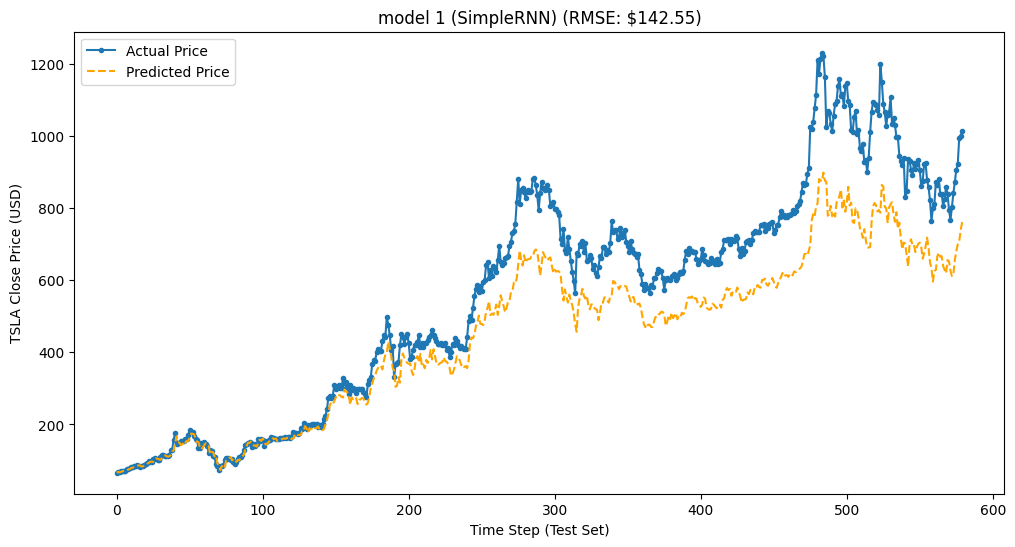

In [14]:
# 1. 실제 값 스케일로 되돌리기
# y_test는 1D, y_pred1은 2D이므로 y_test를 2D로 맞춰줍니다.
y_test_2d = y_test.reshape(-1, 1)

y_test_inv = scaler.inverse_transform(y_test_2d)
y_pred1_inv = scaler.inverse_transform(y_pred1)

# 2. RMSE 계산 (실제 스케일)
# mean_squared_error는 1D 또는 2D 배열 모두 처리 가능
real_mse1 = mean_squared_error(y_test_inv, y_pred1_inv)
real_rmse1 = np.sqrt(real_mse1)
print(f"모델 1 (RNN) 실제 스케일 RMSE: ${real_rmse1:.2f}")

# 3. 그래프 그리기 (모델 1)
plt.figure(figsize=(12, 6))
plt.title(f'model 1 (SimpleRNN) (RMSE: ${real_rmse1:.2f})')
plt.plot(y_test_inv, label='Actual Price', marker='.')
plt.plot(y_pred1_inv, label='Predicted Price', linestyle='--', color='orange')
plt.legend()
plt.xlabel('Time Step (Test Set)')
plt.ylabel('TSLA Close Price (USD)')
plt.show()

In [16]:
# 1. 모델 정의
# input_shape는 X_train의 (타임스텝, 특성 수)를 따릅니다.
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# 2. 모델 컴파일
model_lstm.compile(optimizer='adam', loss='mse')

In [18]:
# 3. 모델 학습
history_lstm = model_lstm.fit(X_train, y_train,
                              epochs=100, # RNN과 동일하게 100 에포크
                              batch_size=32,
                              validation_data=(X_test, y_test),
                              verbose=1)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 2.6320e-04 - val_loss: 0.0039
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 6.8936e-06 - val_loss: 0.0036
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 6.4874e-06 - val_loss: 0.0032
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - loss: 6.1975e-06 - val_loss: 0.0034
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 6.0015e-06 - val_loss: 0.0032
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 5.4848e-06 - val_loss: 0.0032
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 5.4966e-06 - val_loss: 0.0029
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 5.4016e-06 - val_loss: 0.0033
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 4.6337e-06 - val_loss: 0.0030
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 5.3245e-06 - val_loss: 0.0026
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 4.6464e-06 - val_loss: 0.0027
Epoch 12

In [19]:
# 4. 모델 2 예측 및 MSE 계산
y_pred_lstm = model_lstm.predict(X_test)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
print(f"\n모델 2 (LSTM) 정규화 MSE: {mse_lstm:.8f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step

모델 2 (LSTM) 정규화 MSE: 0.00220005


In [20]:
# 5. 실제 값 스케일로 되돌리기
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

In [21]:
# 6. RMSE 계산 (실제 스케일)
real_mse_lstm = mean_squared_error(y_test_inv, y_pred_lstm_inv)
real_rmse_lstm = np.sqrt(real_mse_lstm)
print(f"모델 2 (LSTM) 실제 스케일 RMSE: ${real_rmse_lstm:.2f}")

모델 2 (LSTM) 실제 스케일 RMSE: $57.54


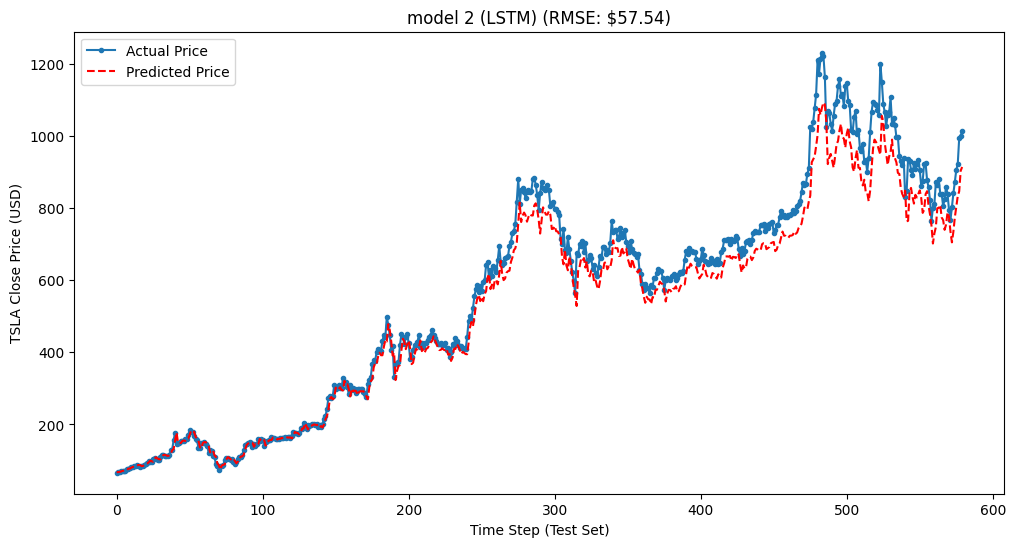

In [24]:
# 7. 그래프 그리기 (모델 2)
plt.figure(figsize=(12, 6))
plt.title(f'model 2 (LSTM) (RMSE: ${real_rmse_lstm:.2f})')
plt.plot(y_test_inv, label='Actual Price', marker='.')
plt.plot(y_pred_lstm_inv, label='Predicted Price', linestyle='--', color='red')
plt.legend()
plt.xlabel('Time Step (Test Set)')
plt.ylabel('TSLA Close Price (USD)')
plt.show()